In [ ]:
import numpy as np
import numpy.random as nr
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


In [ ]:
# Features: SNR (dB), distance (m)
snr = nr.uniform(0, 30, 1000)
distance = nr.uniform(10, 500, 1000)

X = np.column_stack((snr, distance))
decision = 10 + nr.normal(0,3,1000)

# Binary labels: 1 = success, 0 = outage
y = (snr - 0.02*distance > decision).astype(int)
y


array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,

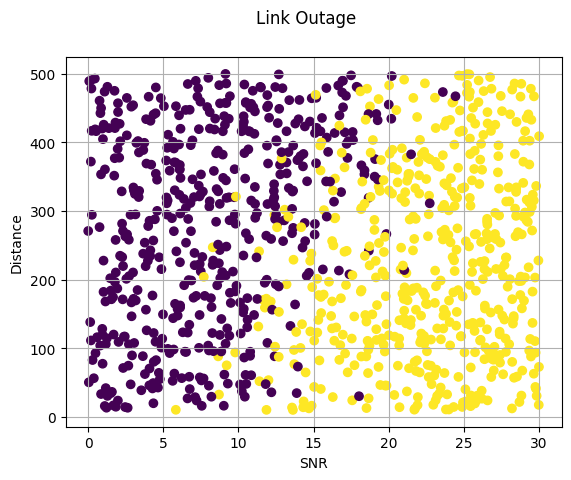

In [ ]:
plt.figure(1);
plt.scatter(X[:, 0], X[:, 1], c = y)
plt.suptitle('Link Outage')
plt.xlabel('SNR')
plt.ylabel('Distance')
plt.grid(1,which='both')
plt.axis('tight')
plt.show()


In [ ]:
model = LogisticRegression()
model.fit(X, y)
y_pred = model.predict(X)

Confusion matrix of Link Outage is 
 [[460  33]
 [ 40 467]] 



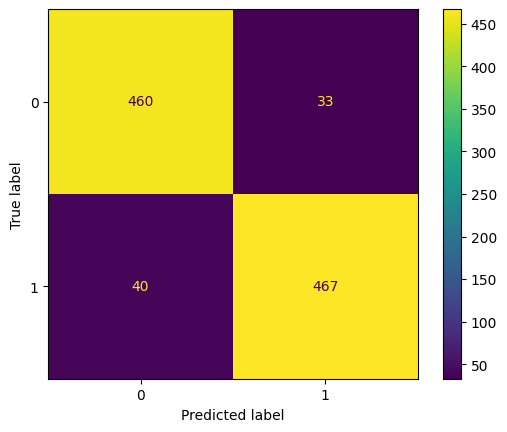

In [ ]:
cmat = confusion_matrix(y, y_pred)
print('Confusion matrix of Link Outage is \n',cmat,'\n')

disp = ConfusionMatrixDisplay(confusion_matrix=cmat)
disp.plot()


In [ ]:
LRscore = accuracy_score(y,y_pred)
print('Accuracy score of Link Outage is',100*LRscore,'%\n')

Accuracy score of Link Outage is 92.7 %



In [10]:
prob=model.predict_proba(X)
prob_1=prob[:,1]
cf=model.coef_;
xplot=np.arange(10,20,0.1)
yplot=-(cf[0,0]*xplot+model.intercept_)/cf[0,1]

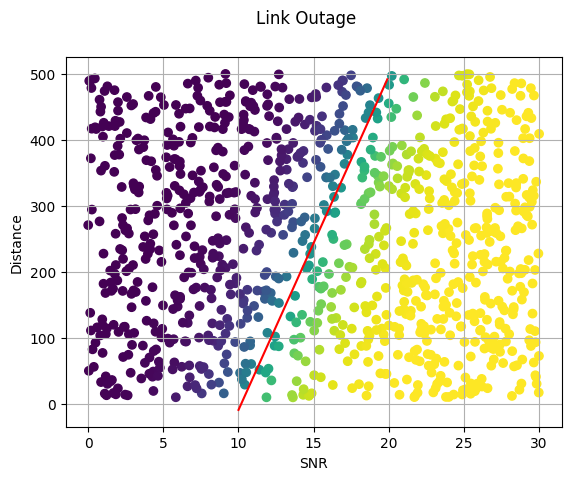

In [11]:
plt.figure(2);
plt.scatter(X[:, 0], X[:, 1], c = prob_1)
plt.plot(xplot,yplot,'r')
plt.suptitle('Link Outage')
plt.xlabel('SNR')
plt.ylabel('Distance')
plt.grid(1,which='both')
plt.axis('tight')
plt.show()